In [1]:
import sys

print(sys.executable)

c:\Program Files\Python312\python.exe


In [1]:
import sys

!{sys.executable} -m pip install shap

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import shap

print(shap.__version__)

0.52.0


In [3]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/teleco_churn.csv")
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

In [5]:
X = X.drop(
    columns=[
        "AvgRevenue",
        "TenureGroup_1-2 Years",
        "TenureGroup_2-4 Years",
        "TenureGroup_4-6 Years"
    ],
    errors="ignore"
)

In [6]:
print(X.shape)

(7043, 13601)


In [7]:
lr = joblib.load(
    "../models/best_model.pkl"
)

In [8]:
explainer = shap.Explainer(
    lr,
    X
)

Background dataset has 7043 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7043 when initializing the masker.


In [12]:
# Use a smaller sample for SHAP analysis to avoid memory issues
sample_size = 100
X_sample = X.sample(n=sample_size, random_state=42)

# Create explainer with the sample
explainer = shap.Explainer(lr, X_sample)

# Calculate SHAP values on the sample
shap_values = explainer(X_sample)

In [13]:
print(X.dtypes)

SeniorCitizen              int64
tenure                     int64
MonthlyCharges           float64
customerID_0003-MKNFE       bool
customerID_0004-TLHLJ       bool
                          ...   
TotalCharges_997.75         bool
TotalCharges_998.1          bool
TotalCharges_999.45         bool
TotalCharges_999.8          bool
TotalCharges_999.9          bool
Length: 13601, dtype: object


In [14]:
print(X.dtypes.value_counts())

bool       13598
int64          2
float64        1
Name: count, dtype: int64


In [15]:
X.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [16]:
X = X.astype(float)

In [17]:
print(X.dtypes.unique())

[dtype('float64')]


In [18]:
import shap

explainer = shap.Explainer(
    lr,
    X
)

shap_values = explainer(X)

Background dataset has 7043 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7043 when initializing the masker.


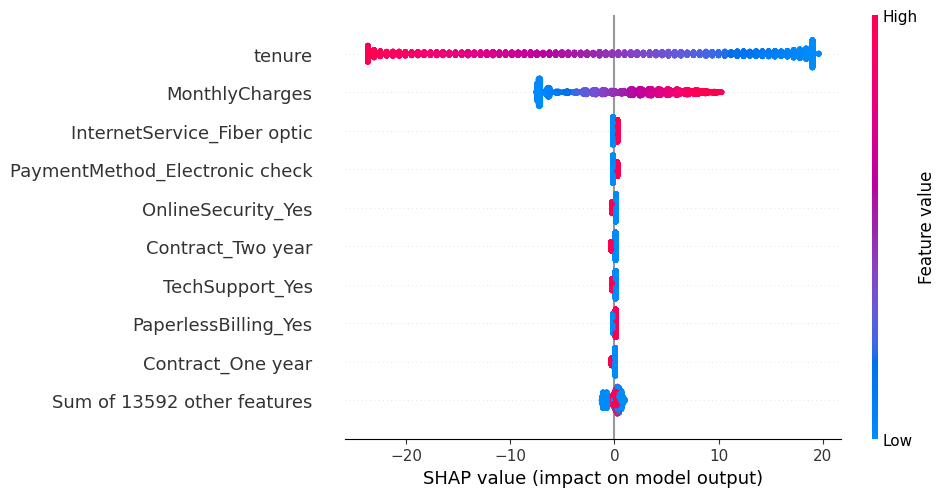

In [19]:
shap.plots.beeswarm(shap_values)